In [1]:
# ========== Module 0: Collect Planning Time ==========
# Test planning time for all methods and save to checkpoint for later plotting and table generation
import sys, json, csv, math
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))
from ExperimentRunner import (
    DuckDBTestRunner, StarCETestRunner, InjectionTestRunner
)

PROJECT_ROOT = Path.cwd()
for parent in [PROJECT_ROOT] + list(PROJECT_ROOT.parents):
    if (parent / "Benchmark").exists() and (parent / "experiment").exists():
        PROJECT_ROOT = parent
        break
if "experiment" in str(PROJECT_ROOT):
    PROJECT_ROOT = PROJECT_ROOT.parent

SB = PROJECT_ROOT / "experiment/checkpoint/SafeBound"
FJ = PROJECT_ROOT / "experiment/checkpoint/FactorJoin"
LP = PROJECT_ROOT / "experiment/checkpoint/LpBound"
BC = PROJECT_ROOT / "experiment/checkpoint/BayesCard"
PC = PROJECT_ROOT / "experiment/checkpoint/EvaluatePlanAndBuild"
PC.mkdir(parents=True, exist_ok=True)
PF = PC / "planning_time.json"
NUM_RUNS = 3
BMS = ["STATS", "JOBM", "JOBLight", "JOBLightRanges"]
results = {}

# ---------- Helper Functions ----------
def read_csv_rows(f):
    with open(f, "r", encoding="utf-8") as fh:
        return list(csv.DictReader(fh))

def sb_card(bm):
    m = {"STATS": "Stats", "JOBM": "JOBM", "JOBLight": "JOBLight", "JOBLightRanges": "JOBLightRanges"}
    return SB / f"SafeBound_3_{m[bm]}_evaluate_results.txt"

def sb_eval(bm):
    bm_key = "Stats" if bm == "STATS" else bm
    for r in read_csv_rows(SB / "benchmark_times.csv"):
        if r["Benchmark"] == bm_key:
            return float(r["EvaluationTime"])

def fj_card(bm):
    for r in read_csv_rows(FJ / "benchmark_times.csv"):
        if r["benchmark"] == bm:
            return Path(r["checkpoint_output"])

def fj_eval(bm):
    for r in read_csv_rows(FJ / "benchmark_times.csv"):
        if r["benchmark"] == bm:
            return float(r["total_eval_like_time_sec"])

def lp_card(bm):
    wm = {"STATS": "STATS-CEB", "JOBLight": "JOBLight"}
    return PROJECT_ROOT / "Benchmark/workloads" / wm[bm] / "subquery/result/lpbound.txt"

def lp_eval(bm):
    with open(LP / "timing_details.json") as f:
        d = json.load(f)
    m = {"STATS": "stats", "JOBLight": "joblight"}
    est = d["estimate_time"][m[bm]]
    return float(est.get("total_parallel_s", 0))

def bc_card(bm):
    for r in read_csv_rows(BC / "benchmark_times.csv"):
        if r["benchmark"] == bm:
            return Path(r["checkpoint_output"])
    raise FileNotFoundError(f"BayesCard cannot find {bm} cardinality file")

def bc_eval(bm):
    for r in read_csv_rows(BC / "benchmark_times.csv"):
        if r["benchmark"] == bm:
            return float(r["total_eval_like_time_sec"])
    raise ValueError(f"BayesCard cannot find {bm}  evaluation time")

# ---------- DuckDB & StarCE ----------
for name, Runner in [("DuckDB", DuckDBTestRunner), ("StarCE", StarCETestRunner)]:
    print(f"=== {name} ===")
    r = Runner(str(PROJECT_ROOT))
    results[name] = {}
    for bm in BMS:
        v = r.test_planning_time(num_runs=NUM_RUNS, benchmarks=[bm])[bm]
        results[name][bm] = v
        print(f"  {bm}: {v:.4f}s")

# ---------- Injected Methods ----------
ir = InjectionTestRunner(str(PROJECT_ROOT))
for name, cg, eg, bms in [
    ("SafeBound", sb_card, sb_eval, BMS),
    ("FactorJoin", fj_card, fj_eval, BMS),
    ("LpBound", lp_card, lp_eval, ["STATS", "JOBLight"]),
    ("BayesCard", bc_card, bc_eval, ["STATS", "JOBLight", "JOBLightRanges"]),
]:
    print(f"=== {name} ===")
    results[name] = {}
    for bm in bms:
        cp = cg(bm)
        et = eg(bm)
        if not cp.exists():
            print(f"  {bm}: Skip (Cardinality file does not exist: {cp})")
            continue
        v = ir.test_planning_time(bm, str(cp), card_est_time=et, num_runs=NUM_RUNS)
        results[name][bm] = v
        print(f"  {bm}: {v:.4f}s")

# ---------- Save ----------
with open(PF, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)
print(f"\nSaved to {PF}")

=== DuckDB ===

=== Testplanning time - DuckDB ===

--- Testplanning time (STATS) ---
[2026-07-11 20:29:39] Starting testplanning time (STATS)，Run 3 
[2026-07-11 20:29:39] Copied queries file to /home/liwei/starCE/experiment/running_space/input.sql and added EXPLAIN
[2026-07-11 20:29:39] Config file saved to: /home/liwei/starCE/experiment/running_space/config.json
[2026-07-11 20:29:39] usinginput.sql: # 1/3 Run...
[2026-07-11 20:29:39] starce Run succeeded，elapsed: 0.40 sec
[2026-07-11 20:29:39] usinginput.sql: # 2/3 Run...
[2026-07-11 20:29:39] starce Run succeeded，elapsed: 0.38 sec
[2026-07-11 20:29:39] usinginput.sql: # 3/3 Run...
[2026-07-11 20:29:40] starce Run succeeded，elapsed: 0.38 sec
[2026-07-11 20:29:40] Config file saved to: /home/liwei/starCE/experiment/running_space/config.json
[2026-07-11 20:29:40] usingdummy_query.sql: # 1/3 Run...
[2026-07-11 20:29:40] starce Run succeeded，elapsed: 0.05 sec
[2026-07-11 20:29:40] usingdummy_query.sql: # 2/3 Run...
[2026-07-11 20:29:40] 

In [1]:
from pathlib import Path

checkpoint_root = Path("checkpoint")

methods = {
    "DuckDB": {
        "type": "planning_only",
        "enabled": True,
        "has_estimate_time": True,
    },
    "StarCE": {
        "csv": checkpoint_root / "StarCE" / "benchmark_times.csv",
        "type": "starce",
        "enabled": True,
        "has_estimate_time": True,
    },
    "SafeBound": {
        "csv": checkpoint_root / "SafeBound" / "benchmark_times.csv",
        "type": "safebound",
        "enabled": True,
        "has_estimate_time": True,
    },
    "Postgre": {
        "csv": checkpoint_root / "Postgre" / "pg_stats_summary.csv",
        "type": "postgre",
        "enabled": True,
        "has_estimate_time": True,
    },
    "FactorJoin": {
        "csv": checkpoint_root / "FactorJoin" / "benchmark_times.csv",
        "type": "factorjoin",
        "enabled": True,
        "has_estimate_time": True,
    },
    "LpBound": {
        "csv": checkpoint_root / "LpBound" / "benchmark_times.csv",
        "type": "lpbound",
        "enabled": True,
        "has_estimate_time": True,
    },
    "BayesCard": {
        "csv": checkpoint_root / "BayesCard" / "benchmark_times.csv",
        "type": "bayescard",
        "enabled": True,
        "has_estimate_time": True,
    },
    "Flat": {
        "type": "planning_only",
        "enabled": True,
        "has_estimate_time": False,
    },
    "DeepDB": {
        "type": "planning_only",
        "enabled": True,
        "has_estimate_time": False,
    },
    "NeuroCard": {
        "type": "planning_only",
        "enabled": True,
        "has_estimate_time": False,
    },
}

# Load planning time data
# Source: checkpoint/EvaluatePlanAndBuild/planning_time.json
# This file is generated from performance_results.json after running EvaluatePerformance.ipynb
planning_json = checkpoint_root / "EvaluatePlanAndBuild" / "planning_time.json"
planning_data = {}
if planning_json.exists():
    import json
    with open(planning_json) as f:
        planning_data = json.load(f)

missing_rule = "separate_x"  # "separate_x" or "any_missing_x"

benchmark_alias = {
    "Stats": "STATS",
    "stats": "STATS",
    "STATS-CEB": "STATS",
    "joblight": "JOBLight",
    "jobrange": "JOBLightRanges",
    "jobm": "JOBM",
}

# JobJoin != JOBM: JobJoin is LpBound exclusive benchmark (full IMDB 21 tables),
# JOBM is the benchmark used by StarCE/SafeBound/FactorJoin.
# The two are different query sets/configurations and should not be merged.

benchmark_order = ["STATS", "JOBM", "JOBLight", "JOBLightRanges"]

size_unit = "MB"  # "bytes", "KB", "MB"

In [2]:
import math
import pandas as pd
import numpy as np


def normalize_benchmark(name: str) -> str:
    key = str(name).strip()
    if key in benchmark_alias:
        return benchmark_alias[key]
    key_upper = key.upper()
    if key_upper in benchmark_alias:
        return benchmark_alias[key_upper]
    return key


def load_method_data(method_name: str, cfg: dict) -> dict:
    if not cfg.get("enabled", True):
        return {}
    method_type = cfg.get("type", "")
    if method_type == "planning_only":
        return {}
    path = Path(cfg["csv"])
    if not path.exists():
        print(f"  Warning: {method_name} CSV file does not exist: {path}")
        return {}
    df = pd.read_csv(path)

    if method_type == "starce":
        df = df.rename(
            columns={
                "benchmark": "benchmark",
                "build_time_sec": "build_time_sec",
                "statistics_size_bytes": "statistics_size_bytes",
            }
        )
    elif method_type == "safebound":
        df = df.rename(
            columns={
                "Benchmark": "benchmark",
                "BuildTime": "build_time_sec",
                "StatisticsSize": "statistics_size_bytes",
            }
        )
        if "statistics_size_bytes" not in df.columns:
            print(f"  Warning: {method_name} CSV Missing StatisticsSize  column, filled with NaN")
            df["statistics_size_bytes"] = np.nan
    elif method_type == "postgre":
        df = df.rename(
            columns={
                "Benchmark": "benchmark",
                "BuildTime": "build_time_sec",
                "StatisticsSize": "statistics_size_bytes",
                "EvaluationTime": "eval_time_sec",
            }
        )
        if "statistics_size_bytes" not in df.columns:
            print(f"  Warning: {method_name} CSV Missing StatisticsSize  column, filled with NaN")
            df["statistics_size_bytes"] = np.nan
    elif method_type == "factorjoin":
        df = df.rename(
            columns={
                "benchmark": "benchmark",
                "total_build_like_time_sec": "build_time_sec",
                "statistics_size_bytes": "statistics_size_bytes",
            }
        )
        if "statistics_size_bytes" not in df.columns:
            print(f"  Warning: {method_name} CSV Missing statistics_size_bytes  column, filled with NaN")
            df["statistics_size_bytes"] = np.nan
    elif method_type == "bayescard":
        df = df.rename(
            columns={
                "benchmark": "benchmark",
                "total_build_like_time_sec": "build_time_sec",
                "statistics_size_bytes": "statistics_size_bytes",
            }
        )
        if "statistics_size_bytes" not in df.columns:
            print(f"  Warning: {method_name} CSV Missing statistics_size_bytes  column, filled with NaN")
            df["statistics_size_bytes"] = np.nan
    elif method_type == "lpbound":
        df = df.rename(
            columns={
                "Benchmark": "benchmark",
                "BuildTime_All": "build_time_sec",
                "StatisticsSize": "statistics_size_bytes",
            }
        )
        df = df[df["benchmark"] != "SubgraphMatching"]
    else:
        print(f"  Warning: {method_name}  type '{method_type}' unknown, skipping")
        return {}

    df["benchmark"] = df["benchmark"].apply(normalize_benchmark)
    result = {}
    for _, row in df.iterrows():
        result[row["benchmark"]] = {
            "build_time_sec": row.get("build_time_sec"),
            "statistics_size_bytes": row.get("statistics_size_bytes"),
            "eval_time_sec": row.get("eval_time_sec"),
        }
    return result


method_results = {
    method_name: load_method_data(method_name, cfg)
    for method_name, cfg in methods.items()
}

benchmark_set = set()
for data in method_results.values():
    benchmark_set.update(data.keys())

if benchmark_order:
    benchmarks = list(benchmark_order)
    for b in sorted(benchmark_set):
        if b not in benchmarks:
            benchmarks.append(b)
else:
    benchmarks = sorted(benchmark_set)
benchmarks = [b for b in benchmarks if b != "SubgraphMatching"]

records = []
for method_name, cfg in methods.items():
    for benchmark in benchmarks:
        entry = method_results.get(method_name, {}).get(benchmark, {})
        build_val = entry.get("build_time_sec")
        size_val = entry.get("statistics_size_bytes")
        method_type = cfg.get("type", "")

        if method_type == "planning_only":
            build_val = None
            size_val = None
            build_missing = True
            size_missing = True
        else:
            build_missing = build_val is None or (isinstance(build_val, float) and math.isnan(build_val))
            size_missing = size_val is None or (isinstance(size_val, float) and math.isnan(size_val))

            if not cfg.get("enabled", True):
                build_missing = True
                size_missing = True
                build_val = None
                size_val = None

            if missing_rule == "any_missing_x" and (build_missing or size_missing):
                build_missing = True
                size_missing = True
                build_val = None
                size_val = None

        # Load planning time -- only valid for methods with has_estimate_time=True
        # Data source priority:
        # 1. plan_time.json (extracted from EvaluatePerformance)
        # 2. Method's own CSV eval_time column (Postgre -- EXPLAIN wall-clock)
        # Methods with has_estimate_time=False (BayesCard/Flat/DeepDB/NeuroCard)
        # did not record actual estimation time and should be marked as missing.
        plan_val = None
        plan_missing = True
        has_plan = cfg.get("has_estimate_time", False)
        if has_plan:
            if planning_data and method_name in planning_data:
                bm_data = planning_data[method_name].get(benchmark)
                if bm_data is not None and not (isinstance(bm_data, float)):
                    bm_data = bm_data.get("planning_time")
                if bm_data is not None and not (isinstance(bm_data, float) and math.isnan(bm_data)):
                    plan_val = float(bm_data)
                    plan_missing = False
            if plan_missing:
                eval_from_csv = entry.get("eval_time_sec")
                if eval_from_csv is not None and not (isinstance(eval_from_csv, float) and math.isnan(eval_from_csv)):
                    plan_val = float(eval_from_csv)
                    plan_missing = False

        records.append(
            {
                "method": method_name,
                "benchmark": benchmark,
                "build_time_sec": build_val,
                "statistics_size_bytes": size_val,
                "build_missing": build_missing,
                "size_missing": size_missing,
                "planning_time_sec": plan_val,
                "planning_missing": plan_missing,
            }
        )

results_df = pd.DataFrame(records)

In [3]:
def format_seconds(value):
    if value is None or (isinstance(value, float) and math.isnan(value)):
        return "X"
    if value < 100:
        return f"{value:.2f}"
    return f"{value:.1f}"


def size_to_unit(value_bytes):
    if value_bytes is None or (isinstance(value_bytes, float) and math.isnan(value_bytes)):
        return None
    if size_unit == "KB":
        return value_bytes / 1024
    if size_unit == "MB":
        return value_bytes / (1024 * 1024)
    return value_bytes


def format_size(value_bytes):
    value = size_to_unit(value_bytes)
    if value is None:
        return "X"
    if value < 100:
        return f"{value:.2f}"
    return f"{value:.1f}"


display_df = results_df.copy()

display_df["build_time_display"] = display_df["build_time_sec"].apply(format_seconds)
display_df["statistics_size_display"] = display_df["statistics_size_bytes"].apply(format_size)
display_df["planning_time_display"] = display_df["planning_time_sec"].apply(format_seconds)

build_table = display_df.pivot(
    index="benchmark",
    columns="method",
    values="build_time_display",
)

size_table = display_df.pivot(
    index="benchmark",
    columns="method",
    values="statistics_size_display",
)

planning_table = display_df.pivot(
    index="benchmark",
    columns="method",
    values="planning_time_display",
)

print("=== Build Time (s) ===")
build_table

print("=== Statistics Size (MB) ===")
size_table

print("=== Planning Time (s) ===")
planning_table

=== Build Time (s) ===
=== Statistics Size (MB) ===
=== Planning Time (s) ===


method,BayesCard,DeepDB,DuckDB,FactorJoin,Flat,LpBound,NeuroCard,Postgre,SafeBound,StarCE
benchmark,,,,,,,,,,
JOBLight,1.06,X,0.10,1.92,X,0.15,X,0.21,0.43,0.11
JOBLightRanges,24.45,X,1.78,38.00,X,X,X,2.79,10.75,1.84
JOBM,X,X,0.59,104.6,X,X,X,1.82,66.55,0.98
JobJoin,X,X,X,X,X,X,X,X,X,0.64
STATS,24.87,X,0.34,30.59,X,0.53,X,0.74,2.62,0.37
STATSJOIN,X,X,X,X,X,X,X,X,X,X
StatsJoin,X,X,X,X,X,X,X,0.26,X,X


/tmp/ipykernel_255189/139861077.py:69: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(rect=(0, 0, 0.82, 1))


ValueError: Image size of 775x97526 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 900x600 with 1 Axes>

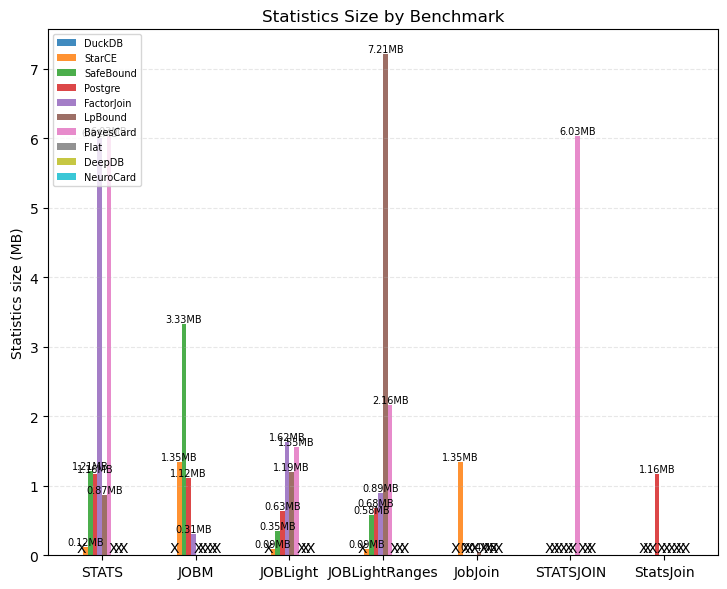

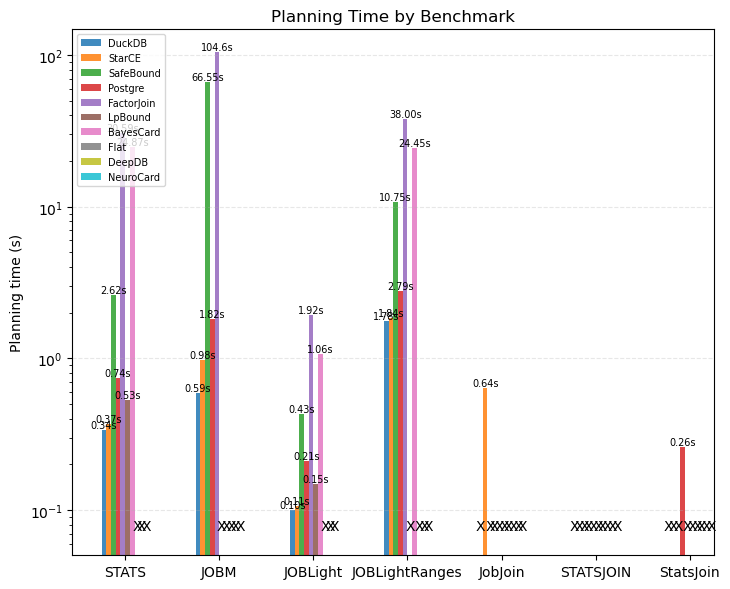

In [4]:
import matplotlib.pyplot as plt


def plot_grouped(metric_col, missing_col, ylabel, title, formatter, log_scale=False):
    method_names = list(methods.keys())
    x = np.arange(len(benchmarks))
    width = 0.5 / max(len(method_names), 1)

    fig, ax = plt.subplots(figsize=(9, 6))

    min_pos = None
    if log_scale:
        for _, row in results_df.iterrows():
            val = row.get(metric_col)
            missing = bool(row.get(missing_col))
            if not missing and val is not None:
                try:
                    val_num = float(val)
                except (TypeError, ValueError):
                    continue
                if val_num > 0:
                    min_pos = val_num if min_pos is None else min(min_pos, val_num)
        if min_pos is None:
            min_pos = 1.0
        y_missing = min_pos * 0.7
    else:
        y_missing = 0

    for i, method_name in enumerate(method_names):
        values = []
        missing_flags = []
        for benchmark in benchmarks:
            row = results_df[
                (results_df["method"] == method_name)
                & (results_df["benchmark"] == benchmark)
            ]
            if row.empty:
                values.append(0)
                missing_flags.append(True)
            else:
                val = row.iloc[0][metric_col]
                missing = bool(row.iloc[0][missing_col])
                if missing or val is None:
                    values.append(np.nan if log_scale else 0)
                else:
                    values.append(float(val))
                missing_flags.append(missing)

        offset = (i - (len(method_names) - 1) / 2) * width
        positions = x + offset
        bars = ax.bar(positions, values, width, label=method_name, alpha=0.85)

        for pos, val, missing in zip(positions, values, missing_flags):
            if missing:
                ax.text(pos, y_missing, "X", ha="center", va="bottom")
            else:
                ax.text(pos, val, formatter(val), ha="center", va="bottom", fontsize=7)

    if log_scale:
        ax.set_yscale("log")
        ax.set_ylim(bottom=min_pos * 0.5)

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(benchmarks)
    ax.legend(loc="upper left", fontsize=7, ncol=1)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    plt.tight_layout(rect=(0, 0, 0.82, 1))
    return fig, ax


def format_time_label(value):
    if value < 100:
        return f"{value:.2f}s"
    return f"{value:.1f}s"


def format_size_label(value):
    if value < 100:
        return f"{value:.2f}{size_unit}"
    return f"{value:.1f}{size_unit}"


results_df["statistics_size_unit"] = results_df["statistics_size_bytes"].apply(size_to_unit)

# --- Build Time Chart ---
fig_time, _ = plot_grouped(
    metric_col="build_time_sec",
    missing_col="build_missing",
    ylabel="Build time (s)",
    title="Build Time by Benchmark",
    formatter=format_time_label,
    log_scale=True,
)
plt.show()

# --- Statistics Size Chart ---
fig_size, _ = plot_grouped(
    metric_col="statistics_size_unit",
    missing_col="size_missing",
    ylabel=f"Statistics size ({size_unit})",
    title="Statistics Size by Benchmark",
    formatter=format_size_label,
)
plt.show()

# --- Planning Time Chart ---
fig_plan, _ = plot_grouped(
    metric_col="planning_time_sec",
    missing_col="planning_missing",
    ylabel="Planning time (s)",
    title="Planning Time by Benchmark",
    formatter=format_time_label,
    log_scale=True,
)
plt.show()

Saved: checkpoint/figures/estimate_time_violin_benchmarks_grouped.pdf


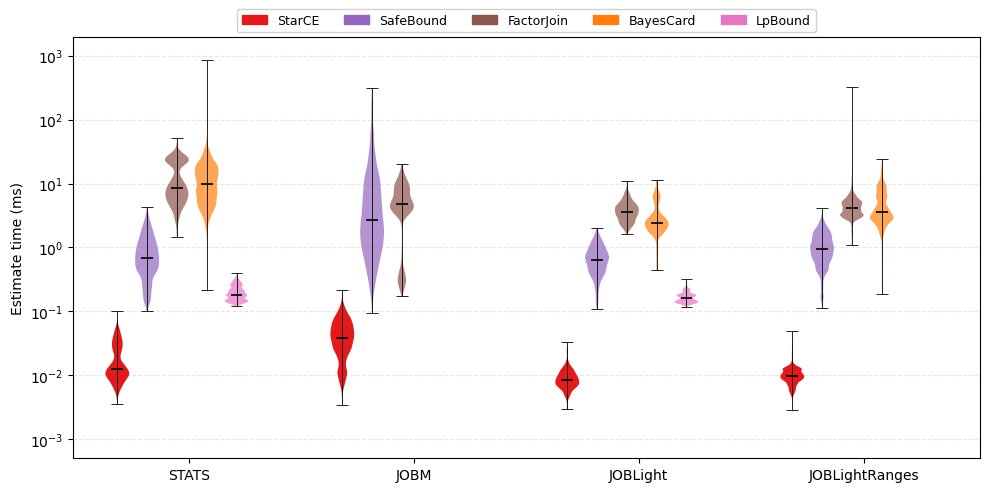


=== Per-SubqueryEstimation timeStatistics (ms) ===


count       mean        std       min       25%  \
method     benchmark                                                          
BayesCard  JOBLight         451.0   3.131809   1.911140  0.438452  1.929522   
           JOBLightRanges  8292.0   4.772774   3.030205  0.183821  2.737761   
           STATS           2471.0  12.117396  18.437410  0.218391  5.540133   
FactorJoin JOBLight         451.0   3.829472   1.410939  1.613617  2.772331   
           JOBLightRanges  8292.0   4.390178   3.863998  1.095533  3.231466   
           JOBM            6424.0   5.333056   3.707162  0.174602  3.483206   
           STATS           2471.0  12.411392   8.492302  1.473427  5.728483   
LpBound    JOBLight        1354.0   0.166222   0.031678  0.118731  0.140579   
           STATS           5662.0   0.196384   0.053935  0.120057  0.150418   
SafeBound  JOBLight         451.0   0.689937   0.350134  0.108719  0.423431   
           JOBLightRanges  8292.0   1.050513   0.585077  0.112772  0.611961   
           JOBM            6424.0   9.775686  24.773163  0.093699  1.063406   
           STATS           2471.0   0.871566   0.666108  0.100136  0.413179   
StarCE     JOBLight         451.0   0.008990   0.003430  0.002924  0.006861   
           JOBLightRanges  8292.0   0.010035   0.003346  0.002804  0.008073   
           JOBM            6424.0   0.043232   0.027886  0.003370  0.022326   
           STATS           2471.0   0.018313   0.012884  0.003534  0.009432   

                                50%        75%         max  
method     benchmark                                        
BayesCard  JOBLight        2.450943   3.135800   11.376381  
           JOBLightRanges  3.579259   6.322682   24.379969  
           STATS           9.742260  16.235709  842.638016  
FactorJoin JOBLight        3.626585   4.549980   10.883808  
           JOBLightRanges  4.065990   5.164921  326.652765  
           JOBM            4.705966   7.661939   20.106792  
           STATS           8.558512  21.285653   51.456928  
LpBound    JOBLight        0.159316   0.183169    0.317523  
           STATS           0.182625   0.228193    0.391378  
SafeBound  JOBLight        0.646114   0.875354    2.032757  
           JOBLightRanges  0.936389   1.404107    4.193544  
           JOBM            2.673030   8.069217  316.555738  
           STATS           0.677347   1.142502    4.346848  
StarCE     JOBLight        0.008361   0.010367    0.032587  
           JOBLightRanges  0.009672   0.011796    0.048583  
           JOBM            0.038018   0.059215    0.216629  
           STATS           0.012399   0.025632    0.100981

In [5]:
# ========== Estimate Time Violin Plot ==========
# Load per-subquery estimate times from each method's estimate_time_*.txt, plot grouped violin chart.
# Data uses log10 (milliseconds), y-axis labels restored as 10^k ms to avoid KDE distortion on log axis.
import sys, os
sys.path.append(os.path.abspath('.'))
import plot_style
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# method -> (checkpoint directory, time unit conversion factor -> milliseconds)
est_methods = {
    "StarCE":      (checkpoint_root / "StarCE",      1.0),
    "SafeBound":   (checkpoint_root / "SafeBound",    1000.0),
    "FactorJoin":  (checkpoint_root / "FactorJoin",   1000.0),
    "BayesCard":   (checkpoint_root / "BayesCard",    1000.0),
    "LpBound":     (checkpoint_root / "LpBound",      1000.0),
}

est_data = []

for method_name, (cp_dir, scale) in est_methods.items():
    for bm_display in benchmark_order:
        time_file = cp_dir / f"estimate_time_{bm_display}.txt"
        if not time_file.exists():
            continue
        with open(time_file) as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                try:
                    t = float(line) * scale
                except ValueError:
                    continue
                est_data.append({
                    "method": method_name,
                    "benchmark": bm_display,
                    "time_ms": t,
                })

est_df = pd.DataFrame(est_data)

if est_df.empty:
    print("not found estimate_time_*.txt files. Please run the Estimation timeexperiments.")
else:
    method_list = [m for m, _ in est_methods.items() if m in est_df["method"].values]
    available_bms = [b for b in benchmark_order if b in est_df["benchmark"].values]
    n_bms = len(available_bms)
    n_methods = len(method_list)

    box_w = 0.16          # Single violin width
    method_gap = 0.04     # Gap between methods within same group
    group_gap = 0.55     # Gap between groups
    group_span = n_methods * box_w + (n_methods - 1) * method_gap

    fig, ax = plt.subplots(figsize=(10, 5))

    positions, datasets, violin_colors, emphasize = [], [], [], []
    for bm_idx, bm in enumerate(available_bms):
        bm_data = est_df[est_df["benchmark"] == bm]
        group_start = bm_idx * (group_span + group_gap)
        for m_idx, method_name in enumerate(method_list):
            method_times = bm_data[bm_data["method"] == method_name]["time_ms"].values
            if len(method_times) == 0:
                continue
            log_times = np.log10(np.maximum(method_times, 1e-6))
            positions.append(group_start + m_idx * (box_w + method_gap))
            datasets.append(log_times)
            violin_colors.append(plot_style.get_method_color(method_name))
            emphasize.append(method_name == "StarCE")

    plot_style.draw_violins(ax, datasets, positions, violin_colors,
                            widths=box_w, emphasize_mask=emphasize)

    # X-axis labels
    tick_positions = [bm_idx * (group_span + group_gap) + group_span / 2
                      for bm_idx in range(n_bms)]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(available_bms)
    ax.set_xlim(-0.3, tick_positions[-1] + group_span / 2 + 0.3)

    # Y-axis: underlying data is log10(ms), tick labels restored as 10^k ms
    all_log = np.concatenate(datasets)
    ymin, ymax = np.floor(all_log.min()), np.ceil(all_log.max())
    ax.set_ylim(ymin - 0.3, ymax + 0.3)
    yticks = np.arange(ymin, ymax + 1)
    ax.set_yticks(yticks)
    ax.set_yticklabels([f"$10^{{{int(t)}}}$" for t in yticks])
    ax.set_ylabel("Estimate time (ms)")
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.set_axisbelow(True)

    legend_patches = [
        mpatches.Patch(color=plot_style.get_method_color(m),
                       label=plot_style.method_display_name(m))
        for m in method_list
    ]
    ax.legend(handles=legend_patches, framealpha=0.9, fontsize=9, ncol=n_methods,
              loc="upper center", bbox_to_anchor=(0.5, 1.08))

    plt.tight_layout()
    figure_dir = checkpoint_root / "figures"
    figure_dir.mkdir(parents=True, exist_ok=True)
    output_file = figure_dir / "estimate_time_violin_benchmarks_grouped.pdf"
    plt.savefig(output_file, bbox_inches="tight")
    print(f"Saved: {output_file}")
    plt.show()

    # Print statistical summary
    print("\n=== Per-SubqueryEstimation timeStatistics (ms) ===")
    summary = est_df.groupby(["method", "benchmark"])["time_ms"].describe()
    display(summary)


In [6]:
# ========== Combined Table: Plan / Space / Build ==========
# Column order: Plan (planning time), Space (statistics size), Build (build time)
# Missing values shown as "–"

def fmt_plan(value):
    """Plan time: sec，two decimal places，Missing values shown –"""
    if value is None or (isinstance(value, float) and math.isnan(value)):
        return "–"
    return f"{value:.2f}"


def fmt_build(value):
    """Build time: sec，one decimal place，Missing values shown –"""
    if value is None or (isinstance(value, float) and math.isnan(value)):
        return "–"
    return f"{value:.1f}"


def fmt_space(value_bytes):
    """Statistics size: MB，Missing values shown –"""
    v = size_to_unit(value_bytes)
    if v is None:
        return "–"
    return f"{v:.1f}"


# Build multi-level columns
estimator_order = [
    "StarCE", "SafeBound", "LpBound", "DuckDB", "Postgre",
    "FactorJoin", "BayesCard", "DeepDB", "Flat", "NeuroCard",
]
bm_order = ["STATS", "JOBM", "JOBLight", "JOBLightRanges"]

metric_labels = ["Plan", "Space", "Build"]

# Create multi-level column index
tuples = []
for bm in bm_order:
    for ml in metric_labels:
        tuples.append((bm, ml))
multi_cols = pd.MultiIndex.from_tuples(tuples)

combined = pd.DataFrame(index=estimator_order, columns=multi_cols)

for method_name in estimator_order:
    for bm in bm_order:
        row = results_df[
            (results_df["method"] == method_name)
            & (results_df["benchmark"] == bm)
        ]
        if row.empty:
            combined.loc[method_name, (bm, "Plan")] = "–"
            combined.loc[method_name, (bm, "Space")] = "–"
            combined.loc[method_name, (bm, "Build")] = "–"
        else:
            r = row.iloc[0]
            combined.loc[method_name, (bm, "Plan")] = fmt_plan(r["planning_time_sec"])
            combined.loc[method_name, (bm, "Space")] = fmt_space(r["statistics_size_bytes"])
            combined.loc[method_name, (bm, "Build")] = fmt_build(r["build_time_sec"])

combined.index.name = "Estimator"
combined

STATS                 JOBM               JOBLight                \
             Plan Space  Build    Plan Space   Build     Plan Space   Build   
Estimator                                                                     
StarCE       0.37   0.1    0.3    0.98   1.3    37.3     0.11   0.1     7.2   
SafeBound    2.62   1.2   17.6   66.55   3.3  1911.9     0.43   0.3   207.8   
LpBound      0.53   0.9   48.8       –     –       –     0.15   1.2    35.7   
DuckDB       0.34     –      –    0.59     –       –     0.10     –       –   
Postgre      0.74   1.2    0.8    1.82   1.1     5.8     0.21   0.6     3.2   
FactorJoin  30.59   6.0   84.8  104.55   0.3   357.1     1.92   1.6  5085.9   
BayesCard   24.87   6.0  140.1       –     –       –     1.06   1.6   755.9   
DeepDB          –     –      –       –     –       –        –     –       –   
Flat            –     –      –       –     –       –        –     –       –   
NeuroCard       –     –      –       –     –       –        –     –       –   

           JOBLightRanges                
                     Plan Space   Build  
Estimator                                
StarCE               1.84   0.1     7.3  
SafeBound           10.75   0.6   378.6  
LpBound                 –   7.2    98.7  
DuckDB               1.78     –       –  
Postgre              2.79   0.7     4.0  
FactorJoin          38.00   0.9  2261.7  
BayesCard           24.45   2.2   997.4  
DeepDB                  –     –       –  
Flat                    –     –       –  
NeuroCard               –     –       –